C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\anuhe\AppData\Local\Temp\ipykernel_15404\1441210447.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ip

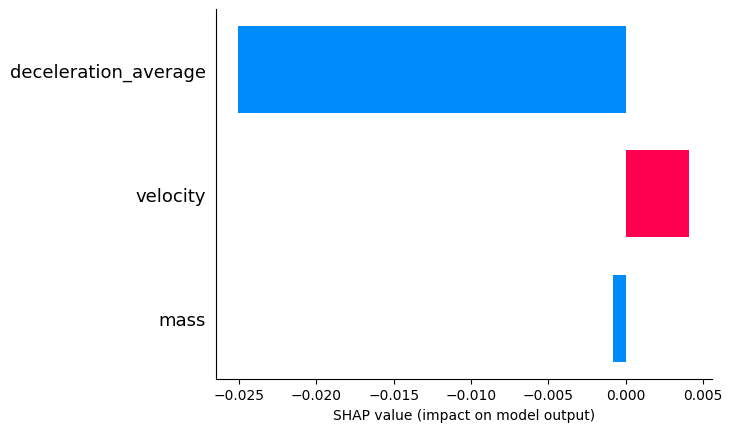

C:\Users\anuhe\AppData\Local\Temp\ipykernel_15404\1441210447.py:152: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


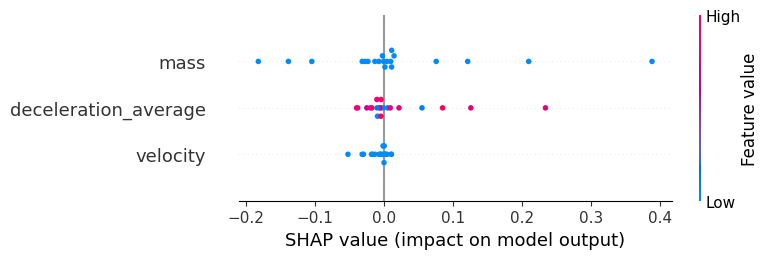

In [1]:
# Explainable AI for LSTM + Tabular Model (SHAP & LIME with GradientExplainer)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt
import pickle

# --- Utility Functions ---
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- Load Data ---
train_path = "C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle"
test_path = "C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle"

train_data = load_pickle(train_path)
test_data = load_pickle(test_path)
train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# --- Imputation and Scaling ---
X_combined = pd.concat([X_train_tab, X_test_tab], ignore_index=True)
imputer = KNNImputer(n_neighbors=5)
X_combined_imputed = imputer.fit_transform(X_combined)

X_train_tab_scaled = StandardScaler().fit_transform(X_combined_imputed[:len(X_train_tab)])
X_test_tab_scaled = StandardScaler().fit(X_combined_imputed).transform(X_combined_imputed[len(X_train_tab):])

sensor_scaler = RobustScaler()
flat_test_scaled = sensor_scaler.fit_transform(X_test_sensor.reshape(-1, 6))
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)

# --- Model Definition ---
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=128, num_layers=2, tabular_dim=3,
                 tab_hidden_dim=16, output_dim=12, dropout=0.5, bidirectional=False):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        lstm_out, _ = self.lstm(x_seq)
        lstm_last = lstm_out[:, -1, :]
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((lstm_last, tab_out), dim=1)
        return self.classifier(combined)

# --- Load Trained Model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier().to(device)
model_path = "C:/Users/anuhe/Documents/GitHub/ss2025-srw-nn/LSTM_Transformer_XGB_Gemini/AUG_LSTM_1_BEST_MODEL.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# --- SHAP (GradientExplainer) with model wrapper ---

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()

    def forward(self, combined_input):
        # combined_input shape: (N, 768 + 3)
        x_seq = combined_input[:, :768].reshape(-1, 128, 6)
        x_tab = combined_input[:, 768:]
        return self.model(x_seq, x_tab)

# Prepare wrapped model and data
wrapped_model = WrappedModel(model)
background = torch.tensor(np.hstack([
    X_test_sensor_clipped[:100].reshape(100, -1),
    X_test_tab_scaled[:100]
]), dtype=torch.float32)

sample_input = torch.tensor(np.hstack([
    X_test_sensor_clipped[0].reshape(1, -1),
    X_test_tab_scaled[0].reshape(1, -1)
]), dtype=torch.float32)

# Use GradientExplainer
explainer = shap.GradientExplainer(wrapped_model, background)
shap_values = explainer.shap_values(sample_input)

# Show tabular SHAP only
feature_names = list(X_test_tab.columns) if hasattr(X_test_tab, 'columns') else [f"feature_{i}" for i in range(X_test_tab_scaled.shape[1])]
shap.bar_plot(
    shap_values[0][0, -len(feature_names):],
    feature_names=feature_names
)

# Get model predictions (to pick the top predicted class per sample)
with torch.no_grad():
    preds = model(
        torch.tensor(X_test_sensor_clipped[:20], dtype=torch.float32),
        torch.tensor(X_test_tab_scaled[:20], dtype=torch.float32)
    )
pred_classes = torch.argmax(preds, dim=1).numpy()

# Pick SHAP values for each predicted class
selected_shap_values = np.array([
    shap_values[class_idx][i] for i, class_idx in enumerate(pred_classes)
])

# Show tabular SHAP values only (last few features)
shap.summary_plot(
    selected_shap_values[:, -len(feature_names):],
    features=X_test_tab_scaled[:20],
    feature_names=feature_names
)


In [3]:

from IPython.display import display

# --- LIME Explanation (tabular only) ---
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_test_tab_scaled,
    feature_names=feature_names,
    class_names=[f"Class {i}" for i in range(12)],
    mode='classification'
)

def predict_tab(x):
    x_seq_rep = np.repeat(X_test_sensor_clipped[0:1], x.shape[0], axis=0)
    with torch.no_grad():
        out = model(
            torch.tensor(x_seq_rep, dtype=torch.float32),
            torch.tensor(x, dtype=torch.float32)
        )
    return torch.nn.functional.softmax(out, dim=1).numpy()

exp = lime_explainer.explain_instance(
    X_test_tab_scaled[0],
    predict_tab,
    num_features=4
)
exp.show_in_notebook()


ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\display.py)